# Shapley Value

- [Online Course](https://www.trainindata.com/p/machine-learning-interpretability)

In this notebook, we calculate Shapley values manually to get an intuition of how they assign feature attribution based on the output of a machine learning model.

In [4]:
from itertools import chain, combinations

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree

import eli5

import plotly.graph_objects as go

## Load data

In [5]:
# load the California House price data from Scikit-learn
X, y = fetch_california_housing(return_X_y=True, as_frame=True)

# We'll work with 3 variables only
X = X[["MedInc", "HouseAge", "Population"]]

# display top 5 rows
X.head()

,MedInc,HouseAge,Population
0,8.3252,41.0,322.0
1,8.3014,21.0,2401.0
2,7.2574,52.0,496.0
3,5.6431,52.0,558.0
4,3.8462,52.0,565.0


In [6]:
# let's separate into training and testing set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((14448, 3), (6192, 3))

## Coalitions

In [7]:
# https://docs.python.org/3/library/itertools.html#itertools-recipes


def powerset(iterable):
    "powerset([1,2,3]) → () (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)"
    s = list(iterable)
    return list(
        chain.from_iterable(combinations(s, r) for r in range(len(s) + 1)))


power_set = powerset(["MedInc", "HouseAge", "Population"])

power_set

[(),
 ('MedInc',),
 ('HouseAge',),
 ('Population',),
 ('MedInc', 'HouseAge'),
 ('MedInc', 'Population'),
 ('HouseAge', 'Population'),
 ('MedInc', 'HouseAge', 'Population')]

The power set contains all the possible coalitions of these 3 features. We'll train a model for each of them to determine the feature contribution with Shapley values.

## The model to interpret

In practice, we have a model with the final set of features, and we want to determine each feature's contribution towards each prediction.

So let's start by training the model we want to interpret.

In [8]:
# to collect intermediate models for Shapley
models = {}

# the model we want to interpret
rf = RandomForestRegressor(n_estimators=5, max_depth=3, random_state=0)

# train model with all features
m = rf.fit(X_train, y_train)

# obtain 5 predictions (reward in game theory)
models["full"] = m.predict(X_test.head())

print(f"model performance; {rf.score(X_test, y_test)}")

# show first predictions
models["full"]

model performance; 0.48709183273438006


array([1.96502044, 3.01134847, 1.96502044, 1.49724468, 2.24098836])

## Architecture of the forest

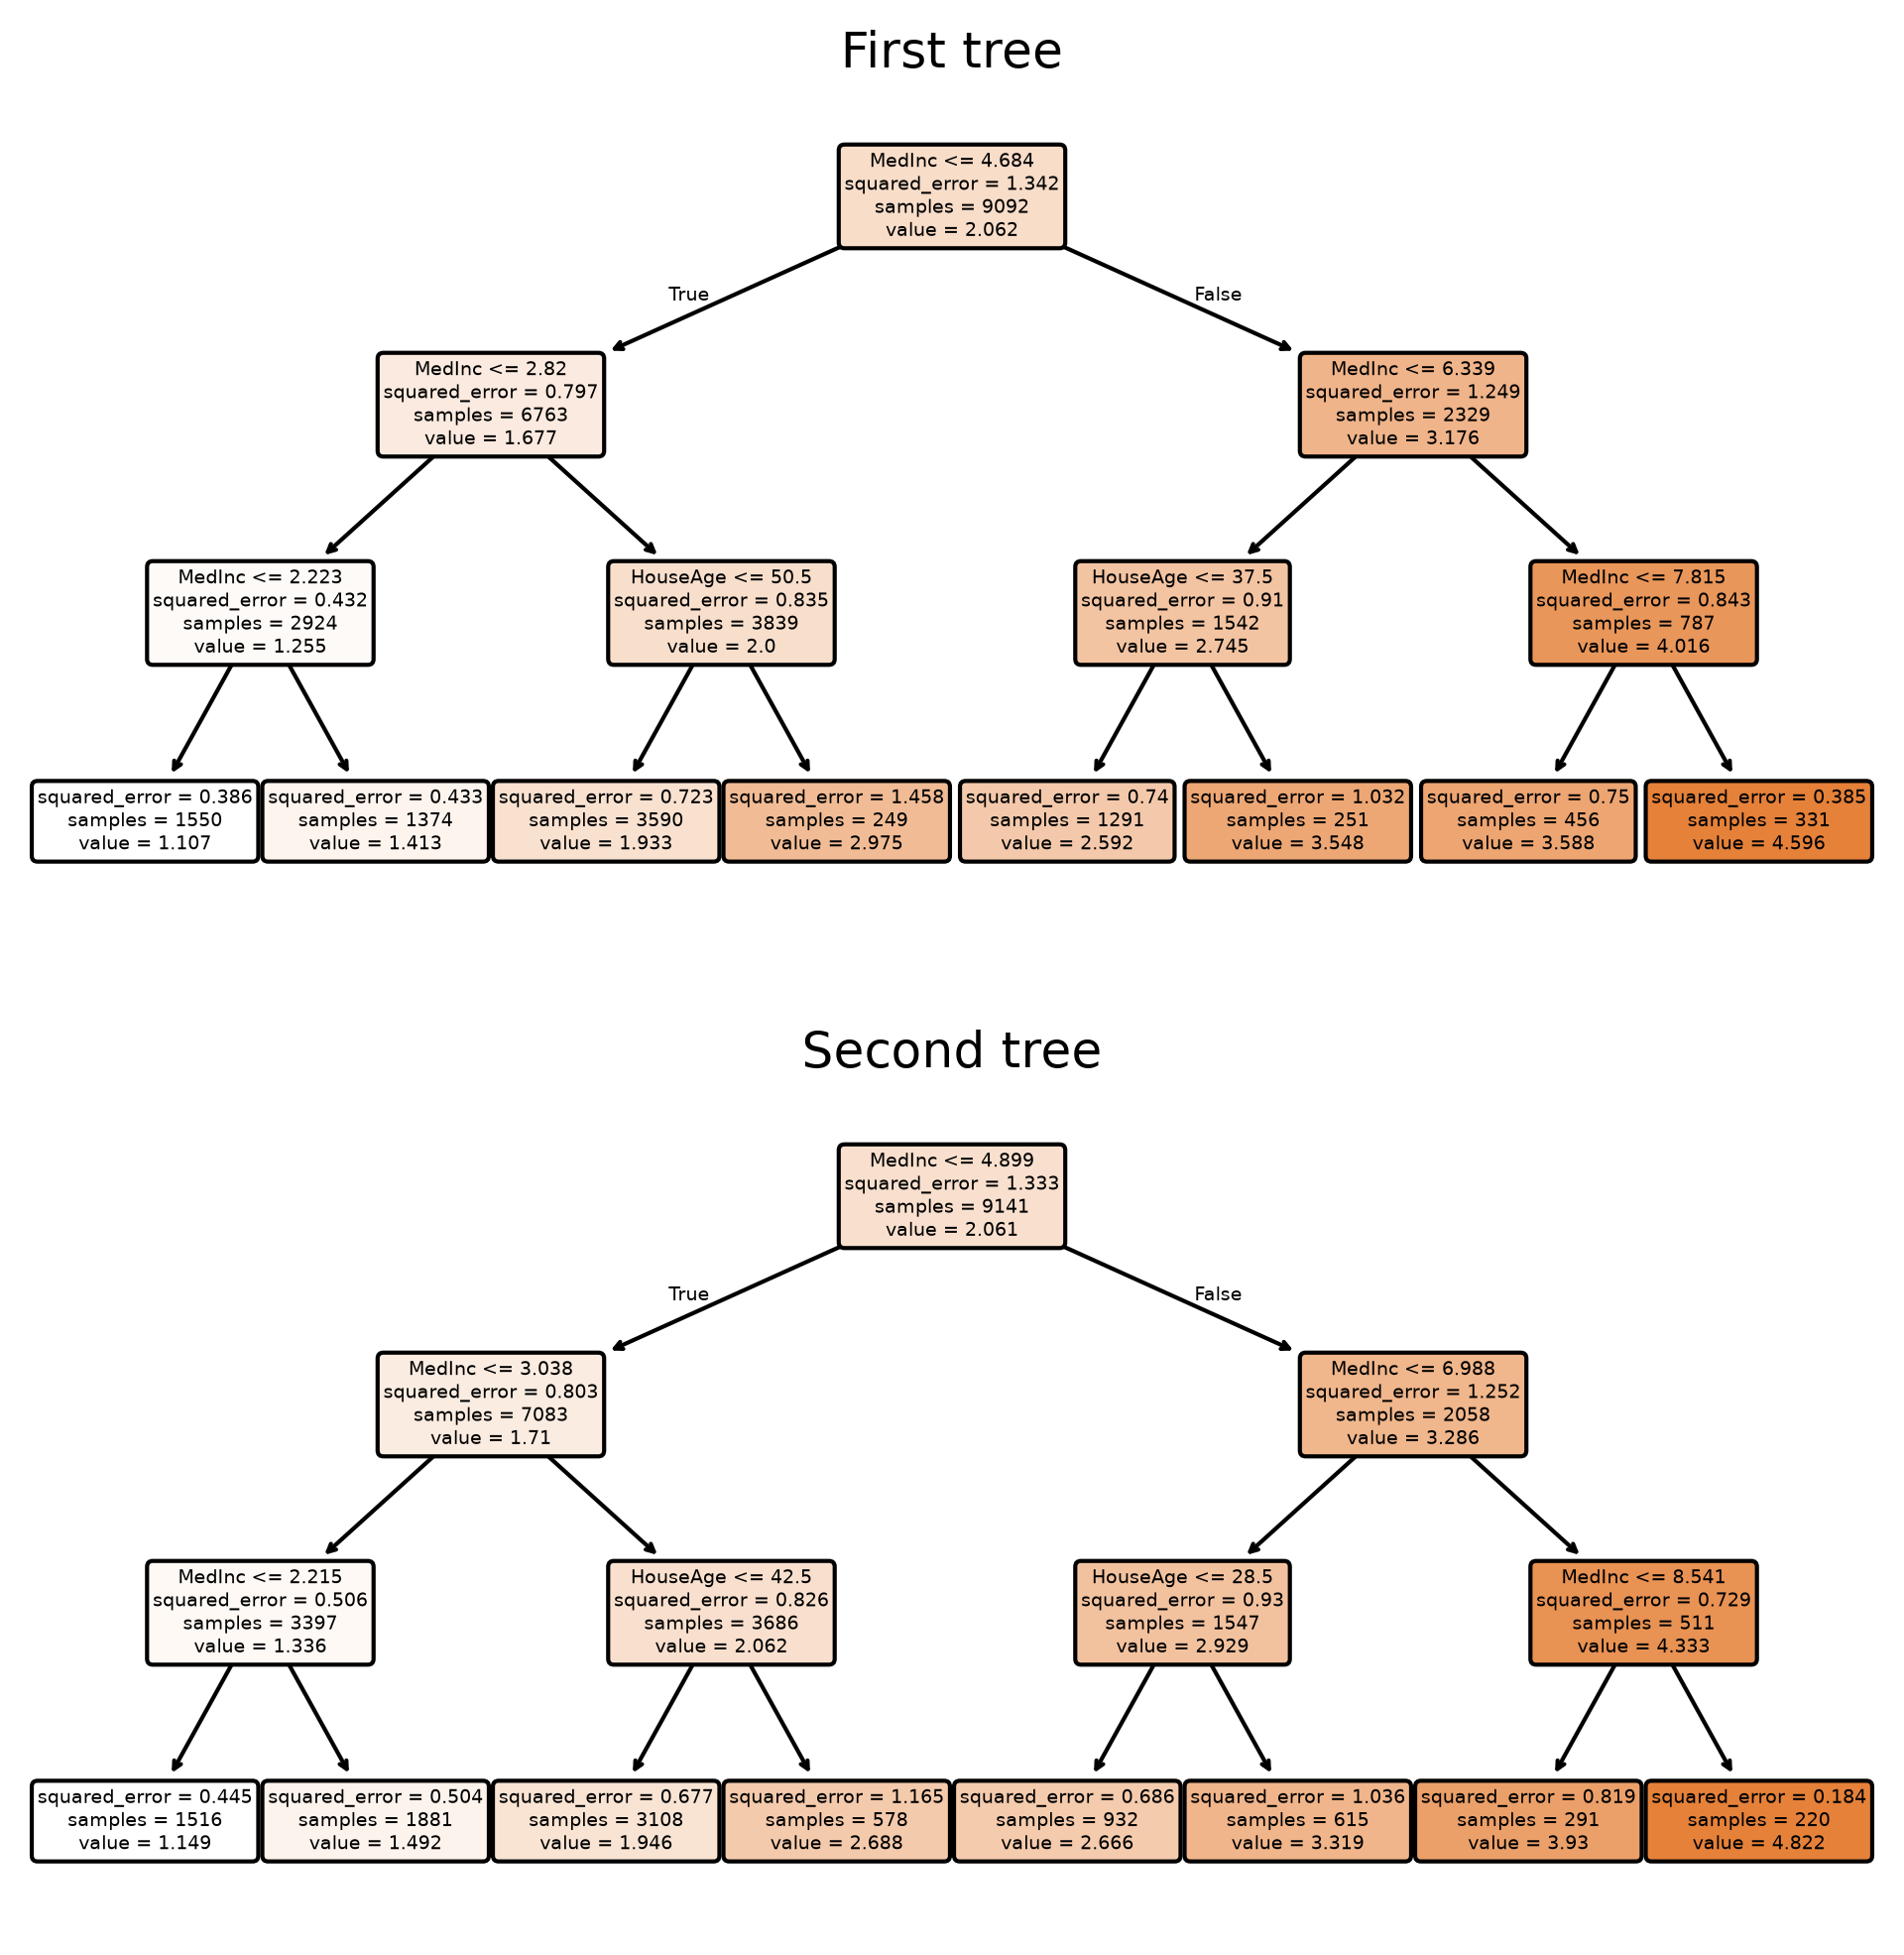

In [9]:
plt.figure(figsize=(8, 8), dpi=300)

# first tree
plt.subplot(2, 1, 1)
plot_tree(
    decision_tree=rf.estimators_[0],
    feature_names=X_train.columns.to_list(),
    filled=True,  # color the squares
    rounded=True  # round squares
)
plt.title("First tree")


# second tree
plt.subplot(2, 1, 2)
plot_tree(
    decision_tree=rf.estimators_[1],
    feature_names=X_train.columns.to_list(),
    filled=True,  # color the squares
    rounded=True  # round squares
)
plt.title("Second tree")

plt.show()

We see that non of the trees contain population (go ahead and plot the remaining 3 trees to be sure).

Population does not contribute to house price based on our Random Forest model.

In [10]:
# interpret feature contribution of the first prediction

row = X_test.iloc[0]

contrib = eli5.explain_prediction_df(rf, row, feature_names=list(X_train.columns))
contrib

/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-pac

,target,feature,weight,value
0,y,<BIAS>,2.059352,1.0000
1,y,MedInc,0.010831,4.1518
2,y,HouseAge,-0.105162,22.0000


We see that Population is a dummy player in all of these games (remember that each prediction is a game).

In [11]:
# the baseline (bias): average prediction across the
# trees' root nodes

contrib.loc[contrib["feature"] == "<BIAS>", "weight"].values[0]

np.float64(2.059351761212611)

In [12]:
# function to create waterfall diagrams

# waterfall diagrams show the change in value returned by
# each feature

def plot_waterfall(contrib):
    base = contrib.loc[contrib["feature"] == "<BIAS>", "weight"].values[0]
    feature_contrib = contrib[contrib["feature"] != "<BIAS>"].set_index("feature")["weight"]

    fig = go.Figure(
        go.Waterfall(
            name="waterfall",
            orientation="h",
            y=feature_contrib.index.to_list(),
            x=feature_contrib.values,
            base=base,
        )
    )
    fig.show()

[1.96502044]


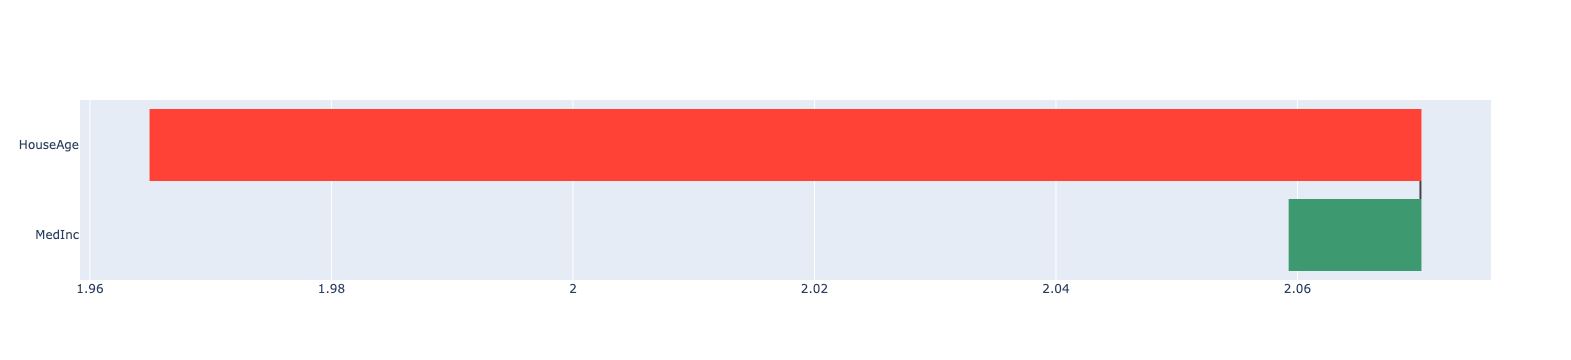

In [13]:
# examine 1 prediction

print(rf.predict(row.to_frame().T))
plot_waterfall(contrib)

[3.01134847]


/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-pac

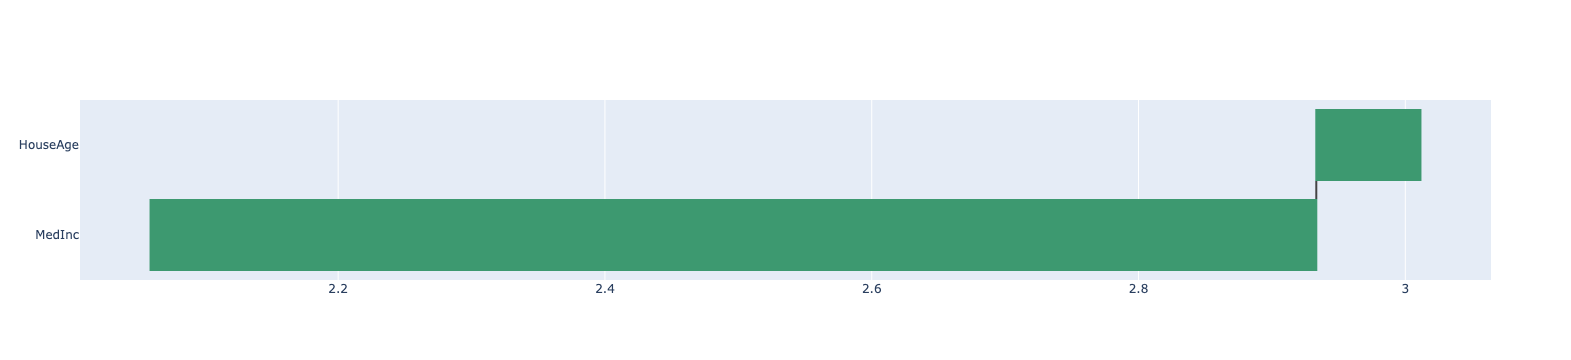

In [14]:
row = X_test.iloc[1]
contrib = eli5.explain_prediction_df(rf, row, feature_names=list(X_train.columns))

print(rf.predict(row.to_frame().T))
plot_waterfall(contrib)

[2.24098836]


/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/interpret/lib/python3.14/site-pac

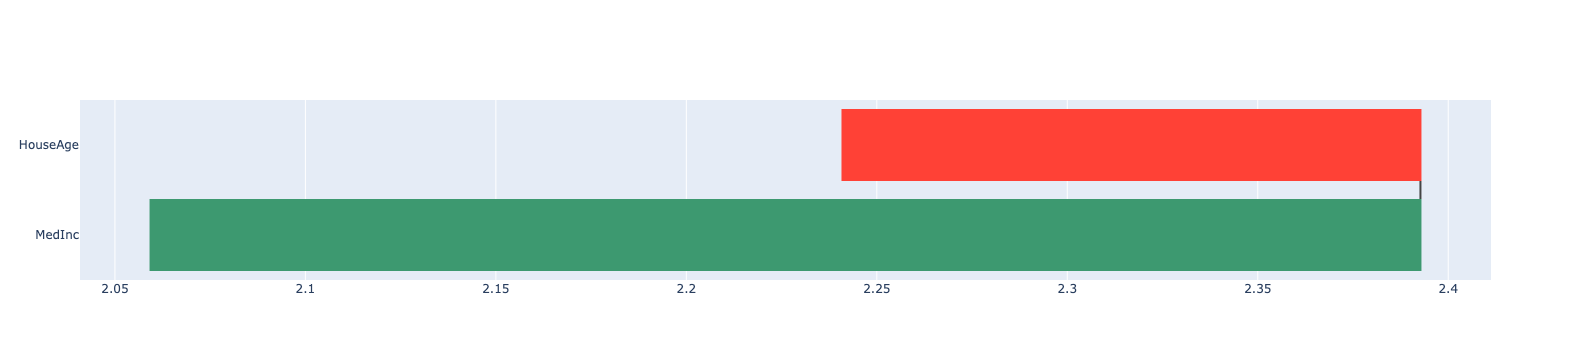

In [15]:
row = X_test.iloc[4]
contrib = eli5.explain_prediction_df(rf, row, feature_names=list(X_train.columns))

print(rf.predict(row.to_frame().T))
plot_waterfall(contrib)

## Shapley values

Now, let's interpret the random forest using Shapley values.

### Empty coalition

First, we need to obtain the reward (prediction) based on a model with no features. That would be the target mean.

In [16]:
# model with no features

models["none"] = [y_train.mean()] * 5

models["none"]

[np.float64(2.0682462451550387),
 np.float64(2.0682462451550387),
 np.float64(2.0682462451550387),
 np.float64(2.0682462451550387),
 np.float64(2.0682462451550387)]

### 1 feature coalitions

Now, we obtain the reward (predictions) for each model trained on any combination of 1 feature.

In [17]:
# models with one feature

for feature in X.columns:
    Xf = X_train[feature].to_frame()
    m = rf.fit(Xf, y_train)
    models[feature] = m.predict(X_test[feature].head().to_frame().head())
    
    print(f"model performance {feature}; {rf.score(X_test[feature].to_frame(), y_test)}")


model performance MedInc; 0.46912041162564466
model performance HouseAge; 0.024580042125791457
model performance Population; 0.0011449094663356085


### 2 feature coalitions

Now, we obtain the reward (predictions) for each model trained on any combination of 2 features.

In [18]:
feature_sets = [list(s) for s in power_set[4:7]]
feature_sets

[['MedInc', 'HouseAge'], ['MedInc', 'Population'], ['HouseAge', 'Population']]

In [19]:
# models with 2 features
for features in feature_sets:
    Xf = X_train[features]
    m = rf.fit(Xf, y_train)
    models[f"{features}"] = m.predict(X_test[features].head())
    
    print(f"model performance {features}; {rf.score(X_test[features], y_test)}")

model performance ['MedInc', 'HouseAge']; 0.48709183273438006
model performance ['MedInc', 'Population']; 0.46912041162564466
model performance ['HouseAge', 'Population']; 0.02798182998093135


In [20]:
# Let's put the results together for clarity:

coalitions_results = pd.DataFrame(models)

coalitions_results.head()

,full,none,MedInc,HouseAge,Population,"['MedInc', 'HouseAge']","['MedInc', 'Population']","['HouseAge', 'Population']"
0,1.965020,2.068246,2.243095,2.081822,1.992165,1.965020,2.243095,2.015151
1,3.011348,2.068246,3.024813,2.038592,1.981484,3.011348,3.024813,1.990566
2,1.965020,2.068246,2.243095,2.038592,1.992165,1.965020,2.243095,1.990566
3,1.497245,2.068246,1.497245,2.038592,2.099530,1.497245,1.497245,2.113449
4,2.240988,2.068246,2.431571,2.081822,2.169133,2.240988,2.431571,2.097857


In the previous dataframe, we see the predictions of random forests trained on 3 features, 1 feature or combinations of 2 features.

### Shapley values

Let's calculate the Shapley values for each game.

In [21]:
sv_medinc = 1/3 * (models["MedInc"] - models["none"]) +\
            1/6 * (models["['MedInc', 'HouseAge']"] - models["HouseAge"]) +\
            1/6 * (models["['MedInc', 'Population']"] - models["Population"]) +\
            1/3 * (models["full"] - models["['HouseAge', 'Population']"])

sv_houseage = 1/3 * (models["HouseAge"] - models["none"]) +\
         1/6 * (models["['MedInc', 'HouseAge']"] - models["MedInc"]) +\
         1/6 * (models["['HouseAge', 'Population']"] - models["Population"]) +\
         1/3 * (models["full"] - models["['MedInc', 'Population']"])

sv_population  = 1/3 * (models["Population"] - models["none"]) +\
         1/6 * (models["['MedInc', 'Population']"] - models['MedInc']) +\
         1/6 * (models["['HouseAge', 'Population']"] - models["HouseAge"]) +\
         1/3 * (models["full"] - models["['MedInc', 'HouseAge']"])

In [22]:
feature_attr = pd.concat(
    [pd.Series(x) for x in [sv_medinc, sv_houseage, sv_population]], 
    axis=1)

feature_attr.columns = X_train.columns

feature_attr.head()

,MedInc,HouseAge,Population
0,0.063927,-0.130681,-0.036472
1,0.995131,-0.015103,-0.036925
2,0.079327,-0.149188,-0.033365
3,-0.586341,-0.007565,0.022904
4,0.239086,-0.102645,0.036301


In the previous dataframe we have the shapley values for each feature for each game (prediction).

In [23]:
# let's add the baseline
feature_attr["base"] = models["none"]

# let's add the feature contributions and the baseline
feature_attr["reward_sum"] = feature_attr.sum(axis=1)

# let's add the full model predictions for comparison
feature_attr["model_output"] = models["full"]

feature_attr.head()

,MedInc,HouseAge,Population,base,reward_sum,model_output
0,0.063927,-0.130681,-0.036472,2.068246,1.965020,1.965020
1,0.995131,-0.015103,-0.036925,2.068246,3.011348,3.011348
2,0.079327,-0.149188,-0.033365,2.068246,1.965020,1.965020
3,-0.586341,-0.007565,0.022904,2.068246,1.497245,1.497245
4,0.239086,-0.102645,0.036301,2.068246,2.240988,2.240988


As expected, the addition of the feature contributions return the predictions of the model.

In [24]:
def plot_waterfall(sample):
    fig = go.Figure(
        go.Waterfall(
            name="waterfall",
            orientation="h",
            y=["MedInc", "HouseAge", "Population"],
            x=[sv_medinc[sample], sv_houseage[sample], sv_population[sample]],
            base=models["none"][sample],
        )
    )
    fig.show()

1.9650204366098802


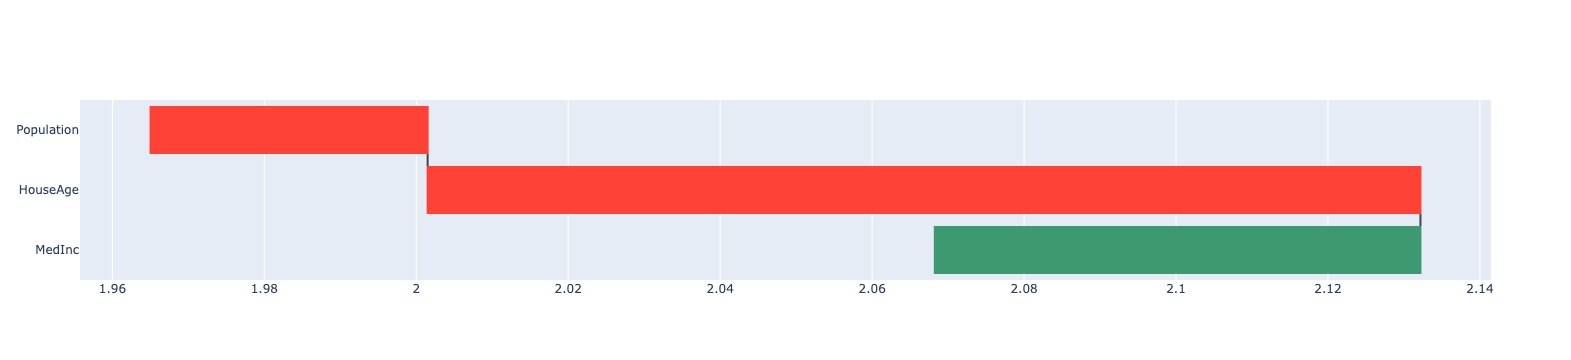

In [25]:
print(models["full"][0])
plot_waterfall(0)

3.011348466838523


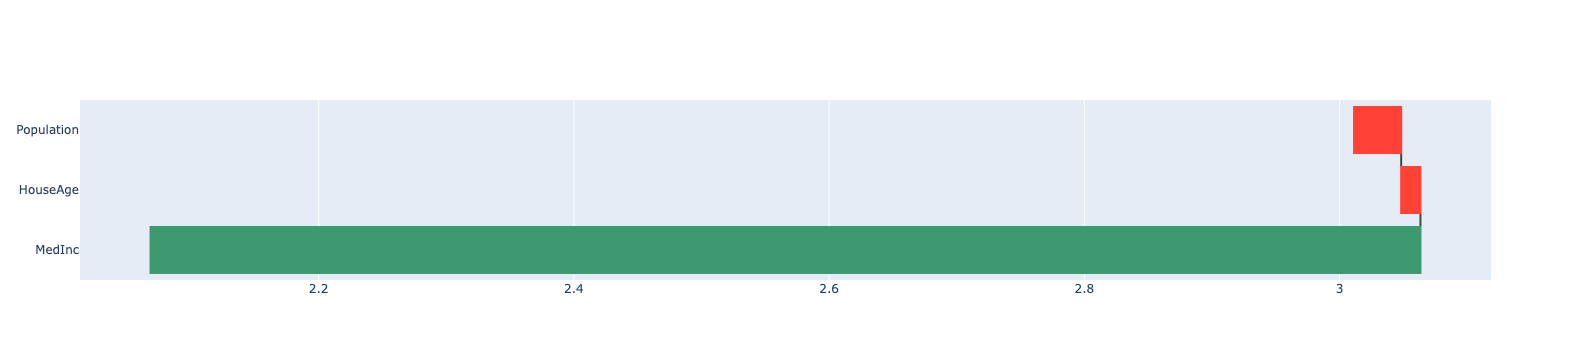

In [26]:
print(models["full"][1])
plot_waterfall(1)

2.2409883612058032


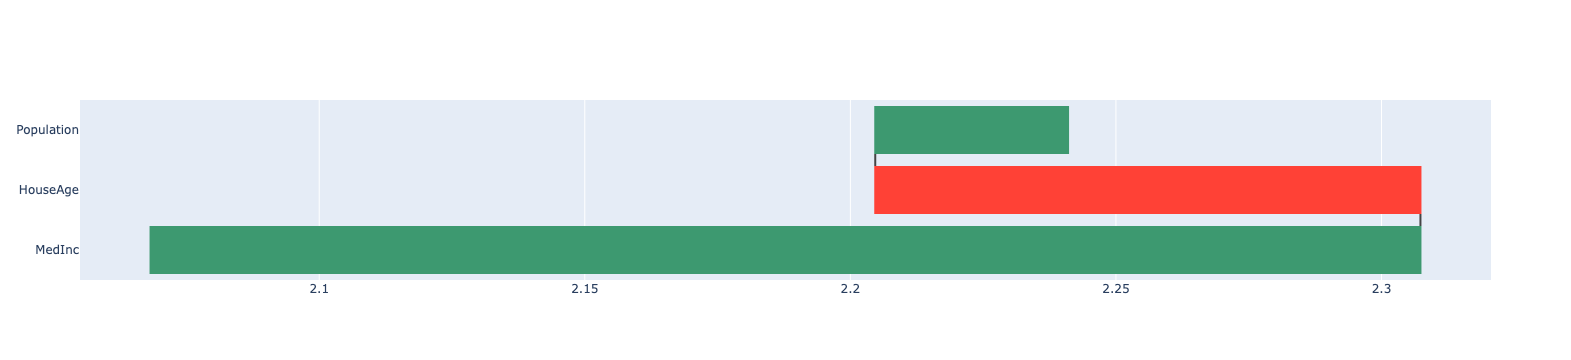

In [27]:
print(models["full"][4])
plot_waterfall(4)

We see that based on Shapley values, the variable Population seems to contribute to the final house price, which does not really coincide with the information we extracted from the tree architecture.

So, does Population contribute or not?

Well, the random forests do not use that variable, so in that sense, the explanations obtained by Shapley values do not reflect the behaviour of the model. Minus point.

On the other hand, we obtained the contributions by training different models and adding up marginal contributions, so it might be that Population, in the absence of other variables, does have a say in the final house price. 

So?

What are we after? 

understanding the role of population in house price? training the best performing model? We need to combine model training with various interpretability methods to fully understand the patterns in our data.